### Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import timm
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from PIL import Image
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix, classification_report

import warnings
warnings.filterwarnings("ignore")

### Train Val Split
- StratifiedGroupKFolds
- 80/20 split
- stratify by `dx`

In [2]:
df = pd.read_csv("/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv")

# n_splits=5 - 80/20 split - 4 parts train, 1 part val
sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=876567
)

train_idx, val_idx = next(sgkf.split(df, df['dx'], df['lesion_id']))
df['split'] = 'train'
df.loc[val_idx, 'split'] = 'val'

# sanity checks
# 1 - Ensure ZERO data leakage across lesion_ids
train_lesions = set(df[df['split'] == 'train']['lesion_id'])
val_lesions = set(df[df['split'] == 'val']['lesion_id'])
overlapping_lesions = train_lesions.intersection(val_lesions)
print(f"Overlapping lesion_ids between Train and Val: {len(overlapping_lesions)}")
assert len(overlapping_lesions) == 0, "Data Leakage Detected!"

# 2 - Check overall split ratio
print("\n--- Split Ratio ---")
print(df['split'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

# 3 - Check class distribution (Stratification check)
print("\n--- Class Distribution by Split (%) ---")
dist_check = pd.crosstab(df['dx'], df['split'], normalize='columns').mul(100).round(2)
print(dist_check)

output_filename = 'HAM10000_metadata_split_80_20.csv'
df.to_csv(output_filename, index=False)
print(f"\nSuccessfully saved fixed split to: {output_filename}")

Overlapping lesion_ids between Train and Val: 0

--- Split Ratio ---
split
train    80.21%
val      19.79%
Name: proportion, dtype: object

--- Class Distribution by Split (%) ---
split  train    val
dx                 
akiec   3.17   3.63
bcc     5.13   5.15
bkl    11.28   9.74
df      1.10   1.36
mel    11.08  11.25
nv     66.80  67.56
vasc    1.44   1.31

Successfully saved fixed split to: HAM10000_metadata_split_80_20.csv


In [3]:
split = pd.read_csv("/kaggle/working/HAM10000_metadata_split_80_20.csv")
split.sample(10)

,lesion_id,image_id,dx,dx_type,age,sex,localization,split
5501,HAM_0003473,ISIC_0024417,nv,follow_up,75.0,male,trunk,val
8617,HAM_0005755,ISIC_0028174,nv,histo,50.0,male,face,train
7261,HAM_0000138,ISIC_0028780,nv,histo,25.0,male,back,train
4403,HAM_0002831,ISIC_0026977,nv,follow_up,45.0,male,lower extremity,train
4019,HAM_0002428,ISIC_0026510,nv,follow_up,70.0,female,trunk,train
6871,HAM_0000837,ISIC_0031555,nv,histo,35.0,female,abdomen,train
4927,HAM_0002482,ISIC_0032064,nv,follow_up,40.0,female,lower extremity,train
2371,HAM_0004791,ISIC_0032538,vasc,histo,80.0,female,lower extremity,train
5182,HAM_0001639,ISIC_0026160,nv,follow_up,55.0,female,trunk,train
85,HAM_0002127,ISIC_0029837,bkl,histo,40.0,male,face,train


In [4]:
train_df = split[split['split'] == "train"]
val_df = split[split['split'] == "val"]

train_df.sample(5)

,lesion_id,image_id,dx,dx_type,age,sex,localization,split
8296,HAM_0001525,ISIC_0025662,nv,histo,35.0,male,upper extremity,train
1298,HAM_0004979,ISIC_0028056,mel,histo,85.0,male,back,train
1566,HAM_0003679,ISIC_0033570,mel,histo,55.0,male,lower extremity,train
2613,HAM_0003887,ISIC_0032906,bcc,histo,65.0,male,face,train
942,HAM_0000080,ISIC_0033528,bkl,consensus,70.0,male,lower extremity,train


In [5]:
print(train_df.shape)
print(val_df.shape)

(8033, 8)
(1982, 8)


### Caching

In [6]:
IMG_SIZE = 380 # EffNet-B4 Native
img_dirs = [
    '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1',
    '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2'
]
label_map = {label : idx for idx, label in enumerate(sorted(split['dx'].unique()))}


# build img_id -> full_path lookup once
path_map = {}
for d in img_dirs:
    for fname in os.listdir(d):
        if fname.endswith('.jpg'):
            image_id = fname[:-4] # strip '.jpg'
            path_map[image_id] = os.path.join(d, fname)

resize_only = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()  # keep as tensor, normalize later at __getitem__ (cheap, no I/O)
])

def build_cache(df, path_map, save_path):
    images = torch.zeros((len(df), 3, 380, 380), dtype=torch.float32)
    for i, row in df.reset_index(drop=True).iterrows():
        img = Image.open(path_map[row['image_id']]).convert('RGB')
        images[i] = resize_only(img)
        if i % 1000 == 0:
            print(f"{i}/{len(df)}")
    torch.save(images, save_path)
    print(f"Saved cache to {save_path}")

# build once, reuse across all 20 epochs
build_cache(train_df, path_map, '/kaggle/working/train_cache.pt')
build_cache(val_df, path_map, '/kaggle/working/val_cache.pt')

0/8033
1000/8033
2000/8033
3000/8033
4000/8033
5000/8033
6000/8033
7000/8033
8000/8033
Saved cache to /kaggle/working/train_cache.pt
0/1982
1000/1982
Saved cache to /kaggle/working/val_cache.pt


### Dataset DataLoader

In [7]:
# class HAMDataset(Dataset):
#     def __init__(self, df, img_dirs, label_map, transform=None):
#         self.df = df.reset_index(drop=True)
#         self.transform = transform
#         self.label_map = label_map

#         # build img_id -> full_path lookup once
#         self.path_map = {}
#         for d in img_dirs:
#             for fname in os.listdir(d):
#                 if fname.endswith('.jpg'):
#                     image_id = fname[:-4] # strip '.jpg'
#                     self.path_map[image_id] = os.path.join(d, fname)

#         print(f"Path Map Sanity Check: {len(self.path_map) == 10015}")

#     def __len__(self):
#         return len(self.df)

#     def __getitem__(self, idx):
#         row = self.df.iloc[idx]
#         img_path = self.path_map[row['image_id']]
#         image = Image.open(img_path).convert("RGB")
#         label = self.label_map[row['dx']]

#         if self.transform:
#             image = self.transform(image)

#         return image, label

class CachedHAMDataset(Dataset):
    def __init__(self, cache_path, df, label_map):
        self.images = torch.load(cache_path)
        self.labels = [label_map[l] for l in df['dx']]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx] # just indexing, nothing else


train_cache_path = "/kaggle/working/train_cache.pt"
val_cache_path = "/kaggle/working/val_cache.pt"

train_dataset = CachedHAMDataset(train_cache_path, train_df, label_map)
val_dataset = CachedHAMDataset(val_cache_path, val_df, label_map)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    drop_last=True,
    num_workers=2,
    pin_memory=True      # faster CPU->GPU transfer
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

### Training

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MEAN = torch.tensor([0.485, 0.456, 0.406], device=device).view(1,3,1,1)
STD = torch.tensor([0.229, 0.224, 0.225], device=device).view(1,3,1,1)

model = timm.create_model("efficientnet_b4", pretrained=True, num_classes=7)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scaler = torch.cuda.amp.GradScaler()

def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)
        images = (images - MEAN) / STD
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device)
            images = (images - MEAN) / STD
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    return running_loss / total, correct / total, macro_f1

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

In [9]:
history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': [],
    'val_f1': []
}

best_f1 = 0.0
NUM_EPOCHS = 20
CHECKPOINT_PATH = 'best_model.pth'

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler, device)
    val_loss, val_acc, val_f1 = validate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_f1': val_f1,
        }, CHECKPOINT_PATH)
        print(f"  → New best model saved (F1: {val_f1:.4f})")

print(f"\nTraining complete. Best Val F1: {best_f1:.4f}")

  0%|          | 0/251 [00:00<?, ?it/s]

Epoch 1/20 | Train Loss: 0.8913 Acc: 0.6931 | Val Loss: 0.6724 Acc: 0.7543 F1: 0.4024
  → New best model saved (F1: 0.4024)


  0%|          | 0/251 [00:00<?, ?it/s]

Epoch 2/20 | Train Loss: 0.4585 Acc: 0.8367 | Val Loss: 0.5702 Acc: 0.8027 F1: 0.5460
  → New best model saved (F1: 0.5460)


  0%|          | 0/251 [00:00<?, ?it/s]

...

Epoch 18/20 | Train Loss: 0.0105 Acc: 0.9964 | Val Loss: 0.9371 Acc: 0.8274 F1: 0.6561


  0%|          | 0/251 [00:00<?, ?it/s]

Epoch 19/20 | Train Loss: 0.0075 Acc: 0.9976 | Val Loss: 0.9253 Acc: 0.8234 F1: 0.6515


  0%|          | 0/251 [00:00<?, ?it/s]

Epoch 20/20 | Train Loss: 0.0057 Acc: 0.9980 | Val Loss: 0.9810 Acc: 0.8269 F1: 0.6425

Training complete. Best Val F1: 0.6581


### Plots

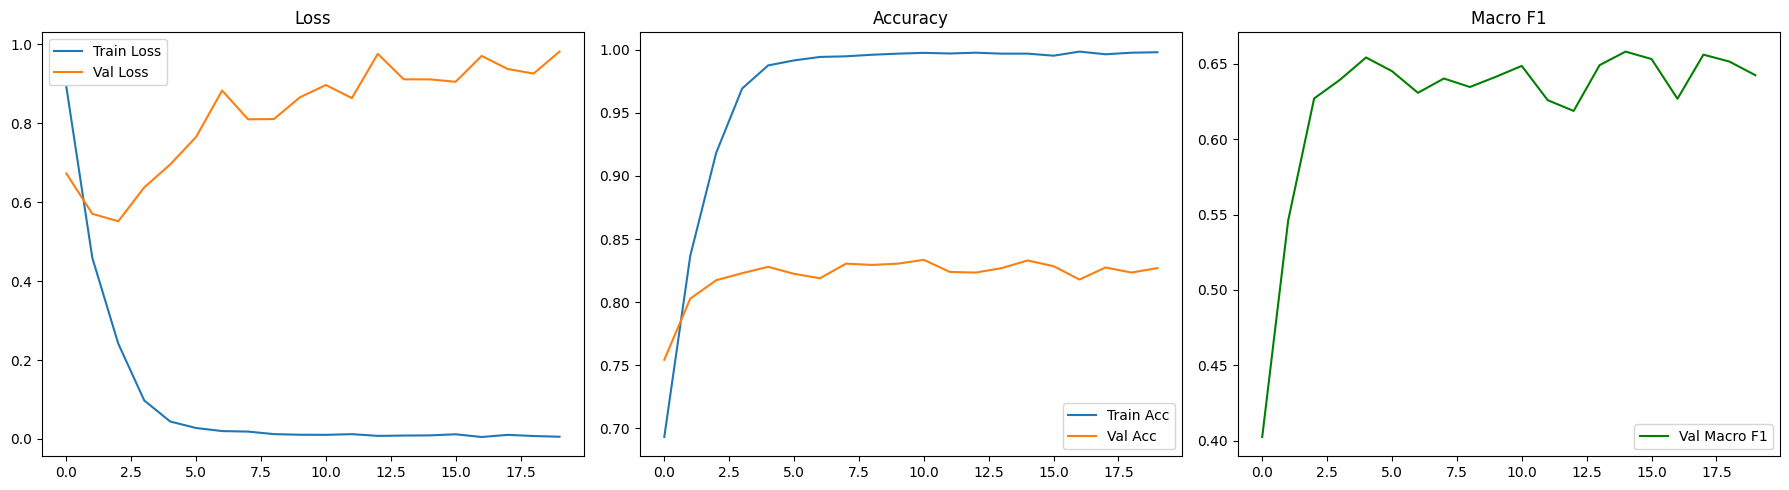

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['val_acc'], label='Val Acc')
axes[1].set_title('Accuracy'); axes[1].legend()

axes[2].plot(history['val_f1'], label='Val Macro F1', color='green')
axes[2].set_title('Macro F1'); axes[2].legend()

plt.tight_layout()
plt.show()

Loaded best model from epoch 15, F1: 0.6581


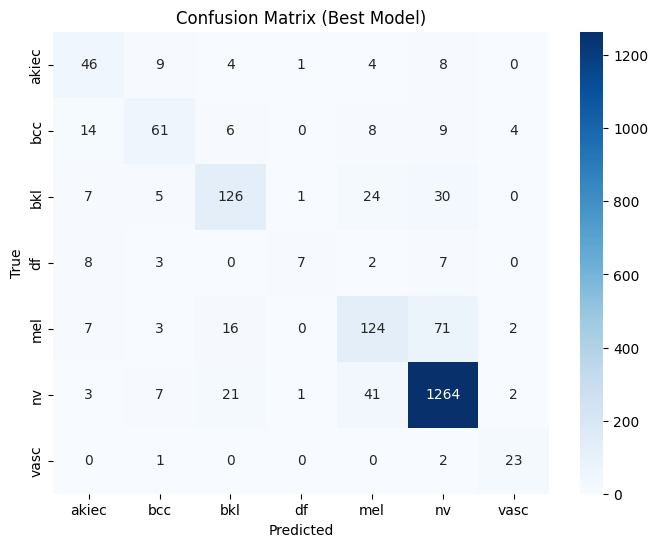

              precision    recall  f1-score   support

       akiec      0.541     0.639     0.586        72
         bcc      0.685     0.598     0.639       102
         bkl      0.728     0.653     0.689       193
          df      0.700     0.259     0.378        27
         mel      0.611     0.556     0.582       223
          nv      0.909     0.944     0.926      1339
        vasc      0.742     0.885     0.807        26

    accuracy                          0.833      1982
   macro avg      0.702     0.648     0.658      1982
weighted avg      0.828     0.833     0.828      1982



In [11]:
checkpoint = torch.load(CHECKPOINT_PATH)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1}, F1: {checkpoint['val_f1']:.4f}")

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        images = (images - MEAN) / STD
        with torch.cuda.amp.autocast():
            outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

class_names = sorted(label_map, key=label_map.get)

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix (Best Model)')
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names, digits=3))